# Fine-tuning de 3 modèles VERIS → ATT&CK (entraînement avec epochs)

Ce notebook entraîne **3 modèles de deep learning** (PyTorch) pour prédire les
techniques MITRE ATT&CK associées à une capacité VERIS (tâche **multi-label**).

## Logique du projet

- **Entraînement** = union des mappings des **anciennes versions**
  (VERIS 1.3.5/ATT&CK 9.0, 1.3.7/12.1, 1.4.0/16.1).
- **Test / classement** = mapping de la **dernière version** (VERIS 1.4.1 / ATT&CK 19.1).
- Quand une nouvelle version sort, on **garde** les anciens mappings et on **ajoute**
  le nouveau (le diff est calculé par `scripts/diff_mappings.py`). Le notebook se
  ré-entraîne alors sur l'union, et la version la plus récente devient le test.

## Les 3 modèles comparés (du plus léger au plus lourd)

1. **MLP sur TF-IDF** — réseau entraîné *from scratch* sur des features sac-de-mots.
2. **MiniLM gelé + tête MLP** — embeddings sémantiques pré-entraînés (figés) + tête entraînée.
3. **DistilBERT fine-tuné** — vrai fine-tuning de bout en bout d'un transformer.

Chaque modèle est entraîné avec une **boucle d'epochs** explicite, puis classé selon
ses résultats sur le mapping 1.4.1/19.1 (précision **et** consommation de ressources).

> Note : après agrégation par capacité, le jeu d'entraînement est petit
> (~157 capacités, ~589 techniques cibles). Il est attendu que le gros transformer
> ne domine pas forcément les baselines — c'est un résultat utile pour le bilan
> « précision vs ressources ».

In [1]:
import sqlite3
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    jaccard_score,
)
from sklearn.preprocessing import MultiLabelBinarizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# --- Localiser la racine du projet et les chemins partagés ---
ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "databases").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

from paths import MAPPINGS_DB, MAPPING_SETS

# --- Configuration de l'expérience ---
TRAIN_SETS = MAPPING_SETS[:3]   # anciennes versions -> entraînement
TEST_SET = MAPPING_SETS[3]      # dernière version   -> test / classement
TOP_K = 10
RANDOM_STATE = 42

# Nombre d'epochs par modèle (configurable)
EPOCHS_MLP = 40            # MLP sur TF-IDF (rapide)
EPOCHS_HEAD = 60           # tête sur embeddings MiniLM gelés (très rapide)
EPOCHS_TRANSFORMER = 6     # fine-tuning DistilBERT (lent sur CPU)
BATCH_SIZE = 16
MAX_LEN = 128              # longueur max de tokens pour le transformer

SBERT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
HF_MODEL = "distilbert-base-uncased"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Projet       : {ROOT}")
print(f"Device       : {DEVICE}")
print(f"Entraînement : {[s[1] for s in TRAIN_SETS]} (VERIS)")
print(f"Test         : {TEST_SET[1]} / ATT&CK {TEST_SET[0]}")

Projet       : C:\Users\simon\Desktop\UQAC\Uqac semestre 2\SIEM
Device       : cpu
Entraînement : ['1.3.5', '1.3.7', '1.4.0'] (VERIS)
Test         : 1.4.1 / ATT&CK 19.1


## 1. Chargement des données (anciens mappings = train, dernier = test)

On charge les mappings depuis la base SQLite, on regroupe les techniques ATT&CK
par capacité VERIS (multi-label), puis on construit :

- `X_train_text` / `y_train` : union des **anciennes** versions ;
- `X_test_text` / `y_test`  : **dernière** version (1.4.1 / 19.1).

L'espace d'étiquettes est l'ensemble des techniques ATT&CK de la **version cible**
(catalogue connu dès qu'on récupère le nouveau bundle ATT&CK).

In [2]:
def load_mappings(db_path, veris_version, attack_version):
    query = """
        SELECT m.capability_id, m.capability_description, m.capability_group,
               m.attack_object_id, m.attack_object_name
        FROM mappings m
        JOIN mapping_sets ms ON m.mapping_set_id = ms.id
        WHERE ms.mapping_framework_version = ? AND ms.attack_version = ?
          AND m.attack_object_id IS NOT NULL AND m.attack_object_id != ''
    """
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(query, conn, params=(veris_version, attack_version))
    df["capability_key"] = df["capability_id"].str.strip().str.lower()
    return df


def aggregate_by_capability(df):
    grouped = (
        df.groupby("capability_key", as_index=False).agg(
            capability_id=("capability_id", "first"),
            capability_description=("capability_description", "first"),
            capability_group=("capability_group", "first"),
            attack_object_ids=("attack_object_id", lambda s: sorted(set(s))),
        )
    )
    grouped["text"] = (
        grouped["capability_group"].fillna("") + " "
        + grouped["capability_id"].fillna("") + " "
        + grouped["capability_description"].fillna("")
    ).str.strip()
    return grouped


train_raw = pd.concat(
    [load_mappings(MAPPINGS_DB, v, a) for a, v, _ in TRAIN_SETS],
    ignore_index=True,
)
test_attack, test_veris, _ = TEST_SET
test_raw = load_mappings(MAPPINGS_DB, test_veris, test_attack)

train_df = aggregate_by_capability(train_raw)
test_df = aggregate_by_capability(test_raw)

# Espace d'étiquettes = techniques ATT&CK de la version cible (test)
label_space = sorted(test_df["attack_object_ids"].explode().dropna().unique())


def filter_labels(techs):
    return [t for t in techs if t in label_space]


train_df["labels"] = train_df["attack_object_ids"].apply(filter_labels)
test_df["labels"] = test_df["attack_object_ids"].apply(filter_labels)
train_df = train_df[train_df["labels"].map(len) > 0].reset_index(drop=True)
test_df = test_df[test_df["labels"].map(len) > 0].reset_index(drop=True)

mlb = MultiLabelBinarizer(classes=label_space)
y_train = mlb.fit_transform(train_df["labels"]).astype("float32")
y_test = mlb.transform(test_df["labels"]).astype("float32")
X_train_text = train_df["text"].tolist()
X_test_text = test_df["text"].tolist()
N_LABELS = len(label_space)

print(f"Exemples d'entraînement : {len(train_df)}")
print(f"Exemples de test        : {len(test_df)}")
print(f"Espace d'étiquettes      : {N_LABELS} techniques ATT&CK ({test_veris}/{test_attack})")
print(f"Moyenne d'étiquettes/exemple (train) : {y_train.sum(axis=1).mean():.2f}")

Exemples d'entraînement : 157
Exemples de test        : 176
Espace d'étiquettes      : 589 techniques ATT&CK (1.4.1/19.1)
Moyenne d'étiquettes/exemple (train) : 9.11


## 2. Fonctions d'évaluation et utilitaires d'entraînement

Métriques identiques au notebook sklearn (`compare_mapping_models_v2`) pour pouvoir
comparer les approches : F1 (micro/macro/samples), Jaccard, Hamming loss,
`precision@k` / `recall@k`, plus le **temps d'entraînement et d'inférence**.

In [3]:
def precision_at_k(y_true, scores, k=TOP_K):
    vals = []
    for i in range(y_true.shape[0]):
        true_idx = set(np.where(y_true[i] == 1)[0])
        if not true_idx:
            continue
        top_k = set(np.argsort(scores[i])[::-1][:k])
        vals.append(len(true_idx & top_k) / k)
    return float(np.mean(vals)) if vals else 0.0


def recall_at_k(y_true, scores, k=TOP_K):
    vals = []
    for i in range(y_true.shape[0]):
        true_idx = set(np.where(y_true[i] == 1)[0])
        if not true_idx:
            continue
        top_k = set(np.argsort(scores[i])[::-1][:k])
        vals.append(len(true_idx & top_k) / len(true_idx))
    return float(np.mean(vals)) if vals else 0.0


def evaluate_model(name, y_scores, train_s, infer_s, threshold=0.5):
    """y_scores = probabilités (n_samples, n_labels). Seuil pour la prédiction binaire."""
    y_pred = (y_scores >= threshold).astype(int)
    metrics = {
        "modèle": name,
        "subset_accuracy": accuracy_score(y_test, y_pred),
        "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_samples": f1_score(y_test, y_pred, average="samples", zero_division=0),
        "jaccard_samples": jaccard_score(y_test, y_pred, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(y_test, y_pred),
        f"precision@{TOP_K}": precision_at_k(y_test, y_scores, TOP_K),
        f"recall@{TOP_K}": recall_at_k(y_test, y_scores, TOP_K),
        "train_time_s": train_s,
        "infer_time_s": infer_s,
    }
    print(
        f"  F1 micro={metrics['f1_micro']:.3f} | "
        f"Jaccard={metrics['jaccard_samples']:.3f} | "
        f"P@{TOP_K}={metrics[f'precision@{TOP_K}']:.3f} | "
        f"R@{TOP_K}={metrics[f'recall@{TOP_K}']:.3f} | "
        f"train={train_s:.1f}s"
    )
    return metrics


def train_torch(model, X, Y, epochs, lr=1e-3, batch_size=BATCH_SIZE,
                weight_decay=1e-4, log_every=10):
    """Boucle d'entraînement générique multi-label (BCEWithLogitsLoss)."""
    model.to(DEVICE)
    # pos_weight aide face au fort déséquilibre (peu de positifs par étiquette)
    pos = Y.sum(axis=0)
    pos_weight = torch.tensor(
        np.clip((len(Y) - pos) / np.clip(pos, 1, None), 1.0, 50.0),
        dtype=torch.float32, device=DEVICE,
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    X_t = torch.tensor(X, dtype=torch.float32)
    Y_t = torch.tensor(Y, dtype=torch.float32)
    ds = torch.utils.data.TensorDataset(X_t, Y_t)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

    t0 = time.perf_counter()
    model.train()
    for epoch in range(1, epochs + 1):
        running = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        if epoch % log_every == 0 or epoch == 1:
            print(f"    epoch {epoch:>3}/{epochs} - loss {running / len(ds):.4f}")
    return time.perf_counter() - t0


@torch.no_grad()
def predict_scores_torch(model, X, batch_size=64):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    out = []
    for i in range(0, len(X_t), batch_size):
        xb = X_t[i:i + batch_size].to(DEVICE)
        out.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.vstack(out)


results = []

## 3. Modèle 1 — MLP entraîné *from scratch* sur TF-IDF

Baseline neuronale : on vectorise le texte (mots + caractères) en TF-IDF, puis un
petit réseau dense est entraîné avec une boucle d'epochs. Aucun téléchargement,
très léger — utile comme référence de consommation de ressources.

In [4]:
print("Modèle 1 : MLP sur TF-IDF")

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray().astype("float32")
X_test_tfidf = tfidf.transform(X_test_text).toarray().astype("float32")
print(f"  Features TF-IDF : {X_train_tfidf.shape}")


class MLP(nn.Module):
    def __init__(self, in_dim, n_labels, hidden=512, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden, n_labels),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(RANDOM_STATE)
mlp = MLP(X_train_tfidf.shape[1], N_LABELS)
train_s = train_torch(mlp, X_train_tfidf, y_train, epochs=EPOCHS_MLP, lr=1e-3)

t1 = time.perf_counter()
scores_mlp = predict_scores_torch(mlp, X_test_tfidf)
infer_s = time.perf_counter() - t1
results.append(evaluate_model("MLP TF-IDF (from scratch)", scores_mlp, train_s, infer_s))

Modèle 1 : MLP sur TF-IDF
  Features TF-IDF : (157, 1452)


    epoch   1/40 - loss 1.1080


    epoch  10/40 - loss 0.6218


    epoch  20/40 - loss 0.2952


    epoch  30/40 - loss 0.1469


    epoch  40/40 - loss 0.0835
  F1 micro=0.630 | Jaccard=0.512 | P@10=0.344 | R@10=0.746 | train=4.2s


## 4. Modèle 2 — Embeddings MiniLM (gelés) + tête MLP entraînée

Transfert d'apprentissage : on encode chaque texte avec un encodeur de phrases
pré-entraîné (`all-MiniLM-L6-v2`, **figé**), puis on entraîne uniquement une tête
dense avec une boucle d'epochs. Rapide et souvent robuste sur petit jeu de données.

> Le premier appel télécharge le modèle MiniLM (~90 Mo).

In [5]:
print("Modèle 2 : MiniLM gelé + tête MLP")

from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer(SBERT_MODEL, device=str(DEVICE))

t_emb = time.perf_counter()
X_train_emb = encoder.encode(X_train_text, convert_to_numpy=True,
                             show_progress_bar=False).astype("float32")
X_test_emb = encoder.encode(X_test_text, convert_to_numpy=True,
                            show_progress_bar=False).astype("float32")
emb_time = time.perf_counter() - t_emb
print(f"  Embeddings : {X_train_emb.shape} (encodage {emb_time:.1f}s)")

torch.manual_seed(RANDOM_STATE)
head = MLP(X_train_emb.shape[1], N_LABELS, hidden=256, p=0.2)
# Le coût d'encodage (modèle gelé) fait partie du temps d'entraînement total
train_s = emb_time + train_torch(head, X_train_emb, y_train, epochs=EPOCHS_HEAD, lr=1e-3)

t1 = time.perf_counter()
scores_head = predict_scores_torch(head, X_test_emb)
infer_s = time.perf_counter() - t1
results.append(evaluate_model("MiniLM gelé + tête MLP", scores_head, train_s, infer_s))

Modèle 2 : MiniLM gelé + tête MLP


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

    epoch  20/60 - loss 0.5497


    epoch  30/60 - loss 0.3761


    epoch  40/60 - loss 0.2881


    epoch  50/60 - loss 0.2381


    epoch  60/60 - loss 0.1957
  F1 micro=0.334 | Jaccard=0.186 | P@10=0.274 | R@10=0.623 | train=5.4s


## 5. Modèle 3 — DistilBERT fine-tuné de bout en bout

Vrai **fine-tuning** : tous les poids de `distilbert-base-uncased` sont mis à jour
sur nos mappings, avec une tête de classification multi-label, sur plusieurs epochs.
C'est le modèle le plus coûteux (téléchargement ~265 Mo, entraînement CPU le plus long).

In [6]:
print("Modèle 3 : DistilBERT fine-tuné")

from transformers import AutoModelForSequenceClassification, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(HF_MODEL)
bert = AutoModelForSequenceClassification.from_pretrained(
    HF_MODEL, num_labels=N_LABELS, problem_type="multi_label_classification",
).to(DEVICE)


def encode_texts(texts):
    enc = tokenizer(texts, truncation=True, padding="max_length",
                    max_length=MAX_LEN, return_tensors="pt")
    return enc["input_ids"], enc["attention_mask"]


train_ids, train_mask = encode_texts(X_train_text)
test_ids, test_mask = encode_texts(X_test_text)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

train_ds = torch.utils.data.TensorDataset(train_ids, train_mask, y_train_t)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

optimizer = torch.optim.AdamW(bert.parameters(), lr=2e-5, weight_decay=1e-2)

t0 = time.perf_counter()
bert.train()
for epoch in range(1, EPOCHS_TRANSFORMER + 1):
    running = 0.0
    for ids, mask, yb in train_loader:
        ids, mask, yb = ids.to(DEVICE), mask.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = bert(input_ids=ids, attention_mask=mask, labels=yb)
        out.loss.backward()
        optimizer.step()
        running += out.loss.item() * len(ids)
    print(f"    epoch {epoch}/{EPOCHS_TRANSFORMER} - loss {running / len(train_ds):.4f}")
train_s = time.perf_counter() - t0


@torch.no_grad()
def bert_scores(ids, mask, batch_size=16):
    bert.eval()
    out = []
    for i in range(0, len(ids), batch_size):
        o = bert(input_ids=ids[i:i + batch_size].to(DEVICE),
                 attention_mask=mask[i:i + batch_size].to(DEVICE))
        out.append(torch.sigmoid(o.logits).cpu().numpy())
    return np.vstack(out)


t1 = time.perf_counter()
scores_bert = bert_scores(test_ids, test_mask)
infer_s = time.perf_counter() - t1
results.append(evaluate_model("DistilBERT fine-tuné", scores_bert, train_s, infer_s))

Modèle 3 : DistilBERT fine-tuné


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

    epoch 3/6 - loss 0.6009


    epoch 4/6 - loss 0.5609


    epoch 5/6 - loss 0.5174


    epoch 6/6 - loss 0.4722


  F1 micro=0.015 | Jaccard=0.006 | P@10=0.013 | R@10=0.015 | train=263.7s


## 6. Comparaison et classement des 3 modèles

Classement sur le mapping **1.4.1 / 19.1** (le test). On regarde la **précision**
(F1 micro, Jaccard, P@k/R@k) ET la **consommation de ressources** (temps
d'entraînement et d'inférence) — les deux critères du projet.

In [7]:
RANK_METRIC = "f1_micro"

results_df = pd.DataFrame(results).sort_values(RANK_METRIC, ascending=False).reset_index(drop=True)
results_df.insert(0, "rang", results_df.index + 1)

display_cols = [
    "rang", "modèle", "f1_micro", "f1_macro", "jaccard_samples",
    f"precision@{TOP_K}", f"recall@{TOP_K}", "hamming_loss",
    "train_time_s", "infer_time_s",
]
ranking = results_df[display_cols].round(4)
print(f"=== Classement des modèles (critère : {RANK_METRIC}) ===")
print(f"Gagnant : {results_df.iloc[0]['modèle']}\n")
ranking

=== Classement des modèles (critère : f1_micro) ===
Gagnant : MLP TF-IDF (from scratch)



,rang,modèle,f1_micro,f1_macro,jaccard_samples,precision@10,recall@10,hamming_loss,train_time_s,infer_time_s
0,1,MLP TF-IDF (from scratch),0.6300,0.6403,0.5124,0.3438,0.7455,0.0127,4.2201,0.0084
1,2,MiniLM gelé + tête MLP,0.3345,0.4572,0.1857,0.2739,0.6232,0.0435,5.3623,0.0044
2,3,DistilBERT fine-tuné,0.0147,0.0005,0.0060,0.0125,0.0155,0.0336,263.6856,8.4391


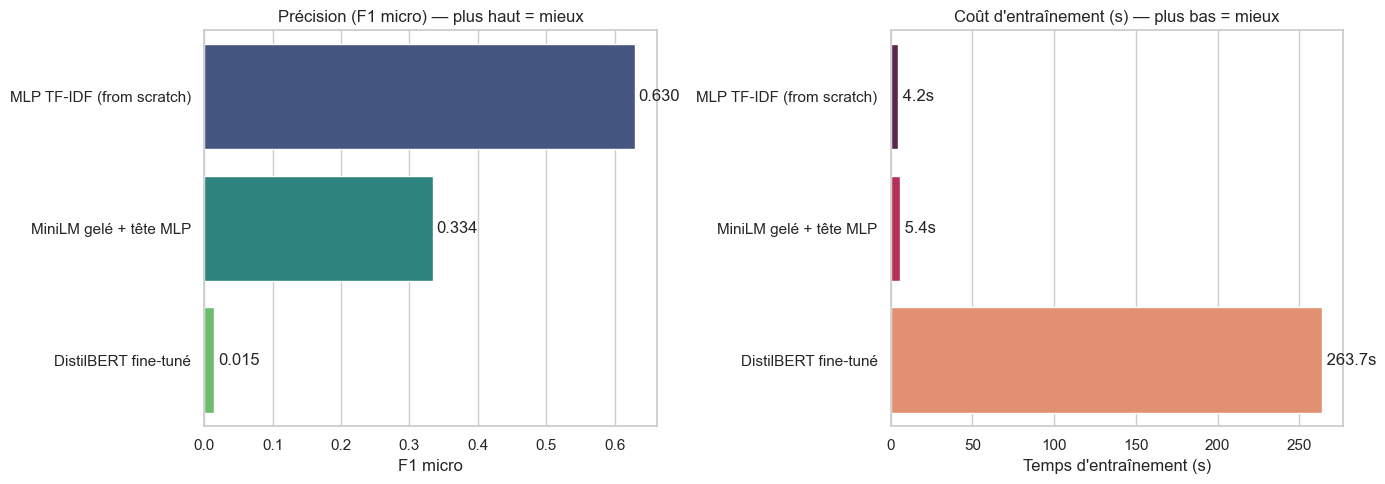

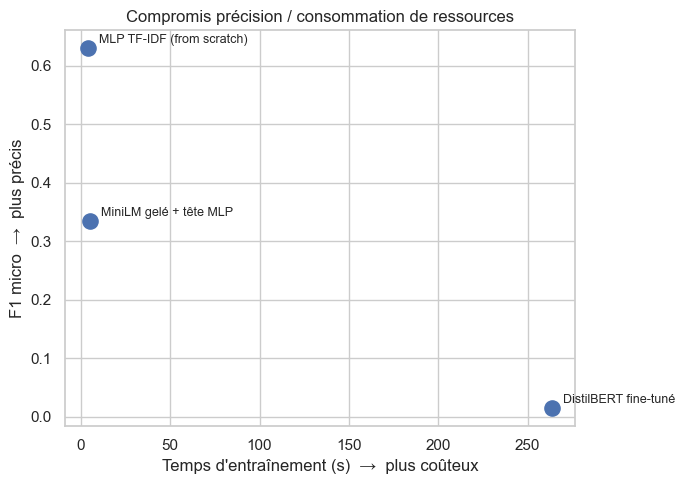

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = results_df["modèle"]
sns.barplot(data=results_df, y="modèle", x="f1_micro", order=order, ax=axes[0],
            palette="viridis")
axes[0].set_title("Précision (F1 micro) — plus haut = mieux")
axes[0].set_xlabel("F1 micro")
axes[0].set_ylabel("")
for i, v in enumerate(results_df["f1_micro"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center")

sns.barplot(data=results_df, y="modèle", x="train_time_s", order=order, ax=axes[1],
            palette="rocket")
axes[1].set_title("Coût d'entraînement (s) — plus bas = mieux")
axes[1].set_xlabel("Temps d'entraînement (s)")
axes[1].set_ylabel("")
for i, v in enumerate(results_df["train_time_s"]):
    axes[1].text(v, i, f" {v:.1f}s", va="center")

plt.tight_layout()
plt.show()

# Compromis précision vs ressources
plt.figure(figsize=(7, 5))
plt.scatter(results_df["train_time_s"], results_df["f1_micro"], s=120)
for _, r in results_df.iterrows():
    plt.annotate(r["modèle"], (r["train_time_s"], r["f1_micro"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)
plt.xlabel("Temps d'entraînement (s)  →  plus coûteux")
plt.ylabel("F1 micro  →  plus précis")
plt.title("Compromis précision / consommation de ressources")
plt.tight_layout()
plt.show()